# Shared-Pool Multi-Tenant Queueing Game Simulator

Models a shared compute node where two independent services compete for CPU via
Generalised Processor Sharing (GPS). Threads act as replicas: the OS time-slices
equally across **all** running threads on the node regardless of service owner.

**Step 1 — base scenario:** two services, fixed replica counts, steady Poisson load.

## 1. Imports

In [29]:
import sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "workflow_simulator")

from simulator.application import Application, LOADMAX
from simulator.infrastructure import Node
from simulator.simulation import Simulation

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Configuration

### 2a. Physical Node

Setting `node.cpu = 1` forces GPS behaviour: the node has a single logical processor
and every running thread receives an equal time-slice.

```
reduced_freq  =  node.freq − δ × R_total
speed         =  reduced_freq / R_total          (per-thread, at full load)
X             =  TASK_LOAD / speed
C_max         =  node.freq / TASK_LOAD           (throughput at R_total = 1, δ = 0)
```

`thread_cpu_overhead` (δ) is the per-thread frequency penalty in op/s:
each active thread steals δ operations/s from the node's available frequency.

In [30]:
# ── Node parameters ────────────────────────────────────────────────
# TASK_LOAD is fixed by the simulator: entry subtask + exit subtask
# = 2 × 0.1 × LOADMAX  (deterministic, no random variation)
TASK_LOAD = int(2 * 0.1 * LOADMAX)   # 1 400 operations per request

# Choose FREQ so that C_max = 1 000 req/s at a single running thread
C_MAX_TARGET = 1_000                 # req/s
FREQ         = TASK_LOAD * C_MAX_TARGET   # = 1 400 000 op/s

NODE_CPU     = 1                     # single shared processor → GPS

# δ in op/s: each active thread removes OVERHEAD op/s from the node's total frequency.
# M_n_actual = FREQ - OVERHEAD × R_total
# Example: OVERHEAD = FREQ * 0.01 → 1% of FREQ stolen per thread.
OVERHEAD     = int(FREQ * 0.02)      # 14 000 op/s per active thread

C_MAX = FREQ / TASK_LOAD             # theoretical max throughput (no overhead)
print(f"TASK_LOAD = {TASK_LOAD} ops")
print(f"FREQ      = {FREQ:,} op/s")
print(f"C_MAX     = {C_MAX:.0f} req/s")
print(f"OVERHEAD  = {OVERHEAD:,} op/s per active thread  ({100*OVERHEAD/FREQ:.1f}% of FREQ)")

TASK_LOAD = 1400 ops
FREQ      = 1,400,000 op/s
C_MAX     = 1000 req/s
OVERHEAD  = 28,000 op/s per active thread  (2.0% of FREQ)


In [31]:
# ── Service configuration ─────────────────────────────────────────
# Change NUM_SERVICES between 2 and 10. The default load is spread across
# services so larger scenarios remain observable instead of immediately
# saturating the shared node.
NUM_SERVICES = 2
TOTAL_LAMBDA_TARGET = 880.0

if not (2 <= NUM_SERVICES <= 10):
    raise ValueError("NUM_SERVICES must be between 2 and 10")

SERVICE_NAMES = [f"Service {i}" for i in range(NUM_SERVICES)]
SERVICE_LAMBDAS = [TOTAL_LAMBDA_TARGET / NUM_SERVICES for _ in range(NUM_SERVICES)]
SERVICE_REPLICAS = [1,1,1,1,1,1,1,1,1,1][:NUM_SERVICES]

# ── Simulation parameters ──────────────────────────────────────────
ITERATIONS    = 50_000   # discrete events to process
EVAL_INTERVAL = 0.2      # seconds between eval callbacks
# timeout=0 means "timeout immediately"; use a large value to disable it
TIMEOUT       = 1e6      # effectively no timeout (1 M seconds ≫ simulation duration)
SEED          = 42

print("Services configured:")
for idx in range(NUM_SERVICES):
    print(f"  {SERVICE_NAMES[idx]}: λ={SERVICE_LAMBDAS[idx]:.1f} req/s, r={SERVICE_REPLICAS[idx]} threads")

Services configured:
  Service 0: λ=440.0 req/s, r=1 threads
  Service 1: λ=440.0 req/s, r=1 threads


## 3. Analytical Predictions

Two complementary models are provided:

| Model | Assumption | When accurate |
|:------|:-----------|:--------------|
| **GPS-PS** | Node is a single Processor Sharing server; `speed = FREQ / (n_running × (1+overhead))` where `n_running` is actual concurrency | Any utilisation — matches the simulator directly |
| **Full-load** (design doc) | All `R_total` threads are simultaneously running | `ρ_per_thread → 1`; the "Tragedy of the Commons" regime |

At low load the GPS-PS model matches the simulation. As load grows and threads stay
permanently busy, both models converge — that convergence point is where the Tragedy
unfolds.

In [32]:
def erlang_c(c: int, a: float) -> float:
    """Erlang C — probability that an arriving request must wait.
    c: number of servers;  a: total offered load (= c × rho)."""
    if c <= 0:
        return 1.0
    rho = a / c
    if rho >= 1.0:
        return 1.0
    poisson_sum = sum(a**k / math.factorial(k) for k in range(c))
    last = (a**c) / (math.factorial(c) * (1.0 - rho))
    return last / (poisson_sum + last)


def predict_gps_ps(service_lambdas, service_replicas, freq, task_load, overhead, service_names=None):
    """GPS / Processor-Sharing model for any number of services."""
    if len(service_lambdas) != len(service_replicas):
        raise ValueError("service_lambdas and service_replicas must have the same length")

    num_services = len(service_lambdas)
    names = service_names if service_names is not None else [f"Service {i}" for i in range(num_services)]

    r_total = sum(service_replicas)
    total_lambda = sum(service_lambdas)
    reduced_freq = max(freq - overhead * r_total, 0.0)
    demand = task_load / reduced_freq if reduced_freq > 0 else float('inf')
    rho_ps = total_lambda * demand

    rows = []
    for idx, (lam, replicas) in enumerate(zip(service_lambdas, service_replicas)):
        name = names[idx]
        if rho_ps >= 1.0:
            rows.append(dict(name=name, lam=lam, r=replicas, stable=False,
                             T_ms=float('inf'), W_q_ms=float('inf'), X_ms=demand * 1000))
            continue
        T = demand / (1.0 - rho_ps)
        rows.append(dict(name=name, lam=lam, r=replicas, stable=True,
                         rho_ps=rho_ps, X_ms=demand * 1000,
                         W_q_ms=(T - demand) * 1000, T_ms=T * 1000))
    return {"rho_ps": rho_ps, "D_ms": demand * 1000, "services": rows}


def predict_full_load(service_lambdas, service_replicas, freq, task_load, overhead, service_names=None):
    """Full-load / design-doc model for any number of services."""
    if len(service_lambdas) != len(service_replicas):
        raise ValueError("service_lambdas and service_replicas must have the same length")

    num_services = len(service_lambdas)
    names = service_names if service_names is not None else [f"Service {i}" for i in range(num_services)]

    r_total = sum(service_replicas)
    reduced_freq = max(freq - overhead * r_total, 0.0)
    speed = reduced_freq / r_total if r_total > 0 else 0.0
    x_ms = task_load / speed * 1000 if speed > 0 else float('inf')

    rows = []
    for idx, (lam, replicas) in enumerate(zip(service_lambdas, service_replicas)):
        name = names[idx]
        capacity = replicas * speed / task_load if task_load > 0 else 0.0
        rho_i = lam / capacity if capacity > 0 else float('inf')
        if rho_i >= 1.0:
            rows.append(dict(name=name, lam=lam, r=replicas, stable=False, rho=rho_i, C_i=capacity,
                             T_ms=float('inf'), W_q_ms=float('inf'), X_ms=x_ms))
            continue
        a = replicas * rho_i
        p_delay = erlang_c(replicas, a)
        w_q = p_delay * (x_ms / 1000) / (2.0 * replicas * (1.0 - rho_i))
        rows.append(dict(name=name, lam=lam, r=replicas, stable=True, rho=rho_i, C_i=capacity,
                         X_ms=x_ms, W_q_ms=w_q * 1000, T_ms=(w_q * 1000) + x_ms))
    return {"R_total": r_total, "X_ms": x_ms, "services": rows}


pred_ps = predict_gps_ps(SERVICE_LAMBDAS, SERVICE_REPLICAS, FREQ, TASK_LOAD, OVERHEAD, SERVICE_NAMES)
pred_fl = predict_full_load(SERVICE_LAMBDAS, SERVICE_REPLICAS, FREQ, TASK_LOAD, OVERHEAD, SERVICE_NAMES)

print("GPS-PS model  (ρ_total =", f"{pred_ps['rho_ps']:.3f})")
for s in pred_ps["services"]:
    print(f"  {s['name']}: X={s['X_ms']:.3f} ms, W_q={s['W_q_ms']:.3f} ms, T={s['T_ms']:.3f} ms")

print(f"\nFull-load model  (X = {pred_fl['X_ms']:.3f} ms, all {pred_fl['R_total']} threads active)")
for s in pred_fl["services"]:
    print(f"  {s['name']}: C_i={s['C_i']:.1f} req/s, ρ={s['rho']:.3f}, "
          f"W_q={s['W_q_ms']:.3f} ms, T={s['T_ms']:.3f} ms")

GPS-PS model  (ρ_total = 0.917)
  Service 0: X=1.042 ms, W_q=11.458 ms, T=12.500 ms
  Service 1: X=1.042 ms, W_q=11.458 ms, T=12.500 ms

Full-load model  (X = 2.083 ms, all 2 threads active)
  Service 0: C_i=480.0 req/s, ρ=0.917, W_q=11.458 ms, T=13.542 ms
  Service 1: C_i=480.0 req/s, ρ=0.917, W_q=11.458 ms, T=13.542 ms


In [33]:
def service_rate_vs_replicas(
    freq: int,
    task_load: int,
    overhead: int,
    other_r_total: int = 0,
    r_min: int = 1,
    r_max: int = 20,
) -> pd.DataFrame:
    """
    Expected service rate (capacity in req/s) of a service for each replica count.

    The node uses GPS: all threads share the CPU equally, and each thread also
    imposes a frequency penalty (overhead). Adding a replica increases both the
    service's share of the CPU *and* the total overhead, so marginal gains diminish.

    The capacity formula (full-load / worst-case model):
        r_total      = r + other_r_total
        reduced_freq = max(freq - overhead * r_total, 0)
        speed        = reduced_freq / r_total        # op/s per thread
        mu           = speed / task_load             # req/s per thread
        capacity     = r * mu                        # max throughput of this service

    Parameters
    ----------
    freq          : node CPU frequency in op/s
    task_load     : CPU operations required per request
    overhead      : per-thread frequency penalty in op/s (delta)
    other_r_total : total replicas of all *other* services on the same node
    r_min         : first replica count to evaluate (default 1)
    r_max         : last  replica count to evaluate (default 20)

    Returns
    -------
    pd.DataFrame indexed by r (replica count) with columns:
        r_total      - total threads on the node (r + other_r_total)
        reduced_freq - effective node frequency after overhead deductions (op/s)
        speed        - CPU speed per thread (op/s)
        mu           - service rate per thread (req/s)
        capacity     - max throughput of this service (req/s = r * mu)
        marginal_gain- extra capacity gained compared to r-1 replicas (req/s)
    """
    records = []
    prev_capacity = 0.0
    for r in range(r_min, r_max + 1):
        r_total = r + other_r_total
        reduced_freq = max(freq - overhead * r_total, 0.0)
        if r_total > 0 and reduced_freq > 0:
            speed    = reduced_freq / r_total
            mu       = speed / task_load
            capacity = r * mu
        else:
            speed = mu = capacity = 0.0
        records.append({
            "r": r,
            "r_total": r_total,
            "reduced_freq": reduced_freq,
            "speed": speed,
            "mu": mu,
            "capacity": capacity,
            "marginal_gain": capacity - prev_capacity,
        })
        prev_capacity = capacity
    return pd.DataFrame(records).set_index("r")


# ── Example: vary replicas of Service 0, all other services keep their current counts ──
other_r = sum(SERVICE_REPLICAS) - SERVICE_REPLICAS[0]
sr = service_rate_vs_replicas(
    freq=FREQ,
    task_load=TASK_LOAD,
    overhead=OVERHEAD,
    other_r_total=other_r,
    r_min=1,
    r_max=10,
)
print(f"Service rate vs replica count  (other_r_total={other_r}, λ_target={SERVICE_LAMBDAS[0]:.0f} req/s)")
print(sr.to_string(float_format=lambda x: f"{x:,.2f}"))

Service rate vs replica count  (other_r_total=1, λ_target=440 req/s)
    r_total  reduced_freq      speed     mu  capacity  marginal_gain
r                                                                   
1         2       1344000 672,000.00 480.00    480.00         480.00
2         3       1316000 438,666.67 313.33    626.67         146.67
3         4       1288000 322,000.00 230.00    690.00          63.33
4         5       1260000 252,000.00 180.00    720.00          30.00
5         6       1232000 205,333.33 146.67    733.33          13.33
6         7       1204000 172,000.00 122.86    737.14           3.81
7         8       1176000 147,000.00 105.00    735.00          -2.14
8         9       1148000 127,555.56  91.11    728.89          -6.11
9        10       1120000 112,000.00  80.00    720.00          -8.89
10       11       1092000  99,272.73  70.91    709.09         -10.91


In [34]:
class AnalyticalAgent:
    """
    Rule-based replica controller grounded in the full-load analytical model.

    On each eval tick the agent observes the current arrival rate λ and the
    replica counts of all other co-located services, then:

      • with probability   p_stay   → keeps the current replica count (no-op)
      • with probability 1-p_stay  → moves to the minimum r* such that
            ρ = λ / capacity(r*) < 1
        i.e. the smallest number of replicas that keeps the service stable
        under the worst-case full-load model.

    Parameters
    ----------
    freq      : node CPU frequency in op/s
    task_load : CPU operations required per request
    overhead  : per-thread frequency penalty in op/s (delta)
    p_stay    : probability of leaving replicas unchanged  (hyperparameter, [0, 1])
    r_max     : upper bound on replica counts to consider
    verbose   : print a decision log at every eval tick
    """

    def __init__(self, freq: int, task_load: int, overhead: int,
                 p_stay: float = 0.5, r_max: int = 5, verbose: bool = False):
        self.freq      = freq
        self.task_load = task_load
        self.overhead  = overhead
        self.p_stay    = p_stay
        self.r_max     = r_max
        self.verbose   = verbose

    def _min_stable_replicas(self, lam: float, other_r_total: int) -> int:
        """Return the smallest r such that capacity(r) > lam (i.e. rho < 1)."""
        sr = service_rate_vs_replicas(
            freq=self.freq,
            task_load=self.task_load,
            overhead=self.overhead,
            other_r_total=other_r_total,
            r_min=1,
            r_max=self.r_max,
        )
        viable = sr[sr["capacity"] > lam]
        return int(viable.index[0]) if not viable.empty else self.r_max

    def on_eval(self, service_idx, service, accumulated, instant):
        lam       = accumulated["services"][service_idx]["arrival_rate"]
        current_r = instant["services"][service_idx]["cpu"]
        other_r_total = sum(
            svc["cpu"]
            for i, svc in enumerate(instant["services"])
            if i != service_idx
        )

        if lam == 0 or np.random.uniform() < self.p_stay:
            if self.verbose:
                reason = "λ=0 (no load yet)" if lam == 0 else f"p_stay roll → stay"
                print(f"  [Agent {service_idx}] STAY   r={current_r}  λ={lam:.1f}  ({reason})")
            return current_r

        target_r = self._min_stable_replicas(lam, other_r_total)
        if self.verbose:
            sr = service_rate_vs_replicas(
                freq=self.freq, task_load=self.task_load, overhead=self.overhead,
                other_r_total=other_r_total, r_min=target_r, r_max=target_r,
            )
            capacity = sr.loc[target_r, "capacity"]
            rho      = lam / capacity if capacity > 0 else float("inf")
            action   = "SCALE UP" if target_r > current_r else ("SCALE DOWN" if target_r < current_r else "STAY*")
            print(f"  [Agent {service_idx}] {action:<10} r: {current_r} → {target_r}  "
                  f"λ={lam:.1f}  C(r*)={capacity:.1f}  ρ={rho:.3f}  other_r={other_r_total}")
        return target_r

## 4. Build & Run the Simulation

Topology: two services, each as an independent single-service workflow (no RPC edges).
Both services are deployed on the **same** `Node`, so their threads compete directly.

In [35]:
np.random.seed(SEED)

if len(SERVICE_LAMBDAS) != NUM_SERVICES or len(SERVICE_REPLICAS) != NUM_SERVICES:
    raise ValueError("Service configuration is inconsistent")

topology = {
    "n_services": NUM_SERVICES,
    "workflows": [
        {"id": idx, "root_service": idx, "edges": [], "lam": SERVICE_LAMBDAS[idx]}
        for idx in range(NUM_SERVICES)
    ],
}

app = Application(topology=topology)
node = Node(id=0, cpu=NODE_CPU, ram=8, freq=FREQ, thread_cpu_overhead=OVERHEAD)

# All services share the same physical node
app.deploy_services({idx: node for idx in range(NUM_SERVICES)})

for idx, replicas in enumerate(SERVICE_REPLICAS):
    app.services[idx].threads = replicas

print("Service deployment:")
for idx in range(NUM_SERVICES):
    print(f"  {SERVICE_NAMES[idx]}: {app.services[idx].threads} threads on Node {app.services[idx].node.id}")
print("Task IDs:", ", ".join(f"wf{idx}={app.workflows[idx].initial_task.id}" for idx in range(NUM_SERVICES)))

Services: 2
Tasktrees: 2
[0]
[1]
Labels: {0: 0, 1: 1}
Service deployment:
  Service 0: 1 threads on Node 0
  Service 1: 1 threads on Node 0
Task IDs: wf0=0, wf1=1


In [36]:
# Passive metrics recorder — collects per-eval-window snapshots
eval_records = []

class PassiveRecorder:
    """Agent that records metrics at every eval window but takes no action."""
    def __init__(self, t_ref):
        self._t = t_ref
        self._seen = set()

    def on_eval(self, service_idx, service, accumulated, instant):
        key = (round(self._t[0], 6), service_idx)
        if key in self._seen:
            return None
        self._seen.add(key)
        eval_records.append({
            "t": self._t[0],
            "service_idx": service_idx,
            "service_name": SERVICE_NAMES[service_idx],
            "service_id": service.id,
            "threads": service.threads,
            "arrival_rate": accumulated["services"][service_idx]["arrival_rate"],
            "departure_rate": accumulated["services"][service_idx]["departure_rate"],
            "avg_latency_ms": accumulated["services"][service_idx]["avg_latency"] * 1000,
            "queue_size": instant["services"][service_idx]["queue_size"],
            "e2e_latency_ms": accumulated["workflows"]["e2e_latencies"][service_idx] * 1000,
            "violation_rate": accumulated["workflows"]["violation_rates"][service_idx],
        })
        return None


# Keep t_ref in sync with sim.t via a forward hook
t_ref = [0.0]

sim = Simulation(
    apps=[app],
    units=[],
    iterations=ITERATIONS,
    eval_interval=EVAL_INTERVAL,
    timeout=TIMEOUT,
)

_orig_forward = sim.forward
def _forward_hook(event):
    _orig_forward(event)
    t_ref[0] = sim.t
sim.forward = _forward_hook

recorder = PassiveRecorder(t_ref)
sim.run(agents={idx: recorder for idx in range(NUM_SERVICES)})
print(f"Simulation finished at t = {sim.t:.2f} s  ({len(sim.history)} traces)")

Simulation finished at t = 33.98 s  (24916 traces)


## 5. Parse Per-Trace Latencies from History

History schema per completed trace:
```
history[trace_id] = {task_id: [t_arrival, t_start, t_departure], "status": 1}
```
- `t_start == t_arrival` when the thread was free (no queueing wait)
- `t_start  > t_arrival` when the task had to queue

In [37]:
wf_task_id = {wf.id: wf.initial_task.id for wf in app.workflows}
per_wf: dict[int, list] = {wf_id: [] for wf_id in range(NUM_SERVICES)}

for trace_id, data in sim.history.items():
    if data["status"] != 1:  # skip timed-out / in-flight traces
        continue
    for wf_id, tid in wf_task_id.items():
        if tid in data:
            ts = data[tid]
            if len(ts) >= 3:
                per_wf[wf_id].append({
                    "t_arr": ts[0],
                    "t_start": ts[1],
                    "t_dep": ts[2],
                    "wait_ms": (ts[1] - ts[0]) * 1000,
                    "exec_ms": (ts[2] - ts[1]) * 1000,
                    "total_ms": (ts[2] - ts[0]) * 1000,
                })

for wf_id in range(NUM_SERVICES):
    print(f"{SERVICE_NAMES[wf_id]}: {len(per_wf[wf_id])} completed traces")

Service 0: 11664 completed traces
Service 1: 13251 completed traces


## 6. Results: Analytical Predictions vs. Simulation

In [38]:
rows = []
for wf_id in range(NUM_SERVICES):
    traces = per_wf[wf_id]
    ps = pred_ps["services"][wf_id]
    fl = pred_fl["services"][wf_id]
    name = SERVICE_NAMES[wf_id]

    if traces:
        totals = [x["total_ms"] for x in traces]
        waits = [x["wait_ms"] for x in traces]
        execs = [x["exec_ms"] for x in traces]
        sim_T = float(np.mean(totals))
        sim_Wq = float(np.mean(waits))
        sim_X = float(np.mean(execs))
        span = traces[-1]["t_dep"] - traces[0]["t_arr"]
        sim_thr = len(traces) / span if span > 0 else 0.0
    else:
        sim_T = sim_Wq = sim_X = sim_thr = float('nan')

    rows.append({
        "Service": name,
        "r / λ": f"{fl['r']} / {fl['lam']:.0f}",
        "[GPS-PS] X (ms)": f"{ps['X_ms']:.3f}",
        "[GPS-PS] W_q": f"{ps['W_q_ms']:.3f}",
        "[GPS-PS] T (ms)": f"{ps['T_ms']:.3f}" if ps["stable"] else "∞",
        "[FL] X (ms)": f"{fl['X_ms']:.3f}",
        "[FL] ρ": f"{fl['rho']:.3f}",
        "[FL] T (ms)": f"{fl['T_ms']:.3f}" if fl["stable"] else "∞",
        "[Sim] X̄ (ms)": f"{sim_X:.3f}",
        "[Sim] W̄_q (ms)": f"{sim_Wq:.3f}",
        "[Sim] T̄ (ms)": f"{sim_T:.3f}",
        "[Sim] thr/s": f"{sim_thr:.1f}",
    })

df = pd.DataFrame(rows).set_index("Service")

print(f"{'NODE':─<70}")
print(f"  GPS-PS total utilisation  ρ_PS = {pred_ps['rho_ps']:.3f}")
print(f"  Full-load exec time       X_FL = {pred_fl['X_ms']:.3f} ms  (all {pred_fl['R_total']} threads active)")
print()
print("[GPS-PS] = Processor Sharing model (matches simulator)  [FL] = Full-load / design-doc  [Sim] = measured")
display(df)

NODE──────────────────────────────────────────────────────────────────
  GPS-PS total utilisation  ρ_PS = 0.917
  Full-load exec time       X_FL = 2.083 ms  (all 2 threads active)

[GPS-PS] = Processor Sharing model (matches simulator)  [FL] = Full-load / design-doc  [Sim] = measured


,r / λ,[GPS-PS] X (ms),[GPS-PS] W_q,[GPS-PS] T (ms),[FL] X (ms),[FL] ρ,[FL] T (ms),[Sim] X̄ (ms),[Sim] W̄_q (ms),[Sim] T̄ (ms),[Sim] thr/s
Service,,,,,,,,,,,
Service 0,1 / 440,1.042,11.458,12.500,2.083,0.917,13.542,1.810,5.182,6.992,445.4
Service 1,1 / 440,1.042,11.458,12.500,2.083,0.917,13.542,1.715,4.205,5.920,438.6


## 7. Latency Distributions

/var/folders/kc/xn48m7qj5d97pqlkh_zwbk7h0000gn/T/ipykernel_18880/324914848.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", NUM_SERVICES)


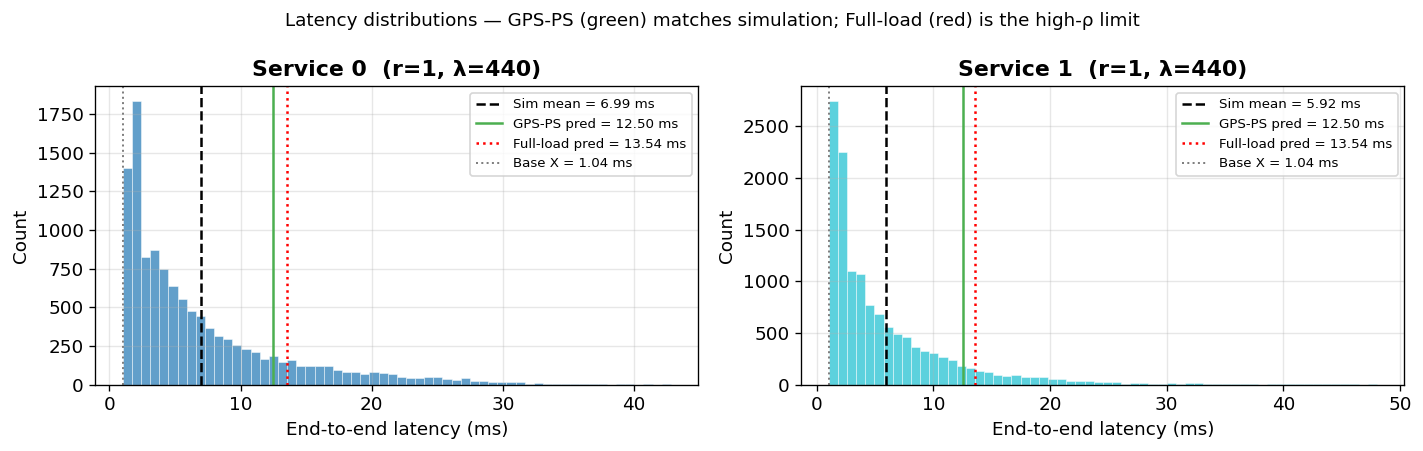

In [39]:
ncols = 2 if NUM_SERVICES > 1 else 1
nrows = math.ceil(NUM_SERVICES / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.8 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)
colors = plt.cm.get_cmap("tab10", NUM_SERVICES)

for wf_id in range(NUM_SERVICES):
    ax = axes[wf_id]
    name = SERVICE_NAMES[wf_id]
    ps = pred_ps["services"][wf_id]
    fl = pred_fl["services"][wf_id]
    data = [x["total_ms"] for x in per_wf[wf_id]]

    ax.hist(data, bins=60, color=colors(wf_id), alpha=0.7, edgecolor="white", linewidth=0.4)
    if data:
        ax.axvline(np.mean(data), color="black", linestyle="--", lw=1.5,
                   label=f"Sim mean = {np.mean(data):.2f} ms")
    ax.axvline(ps["T_ms"], color="#4CAF50", linestyle="-", lw=1.5,
               label=f"GPS-PS pred = {ps['T_ms']:.2f} ms")
    ax.axvline(fl["T_ms"], color="red", linestyle=":", lw=1.5,
               label=f"Full-load pred = {fl['T_ms']:.2f} ms")
    ax.axvline(ps["X_ms"], color="grey", linestyle=":", lw=1.2,
               label=f"Base X = {ps['X_ms']:.2f} ms")

    ax.set_xlabel("End-to-end latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}  (r={fl['r']}, λ={fl['lam']:.0f})", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[NUM_SERVICES:]:
    ax.axis("off")

fig.suptitle("Latency distributions — GPS-PS (green) matches simulation; Full-load (red) is the high-ρ limit", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Time-Series: Metrics Over Eval Windows

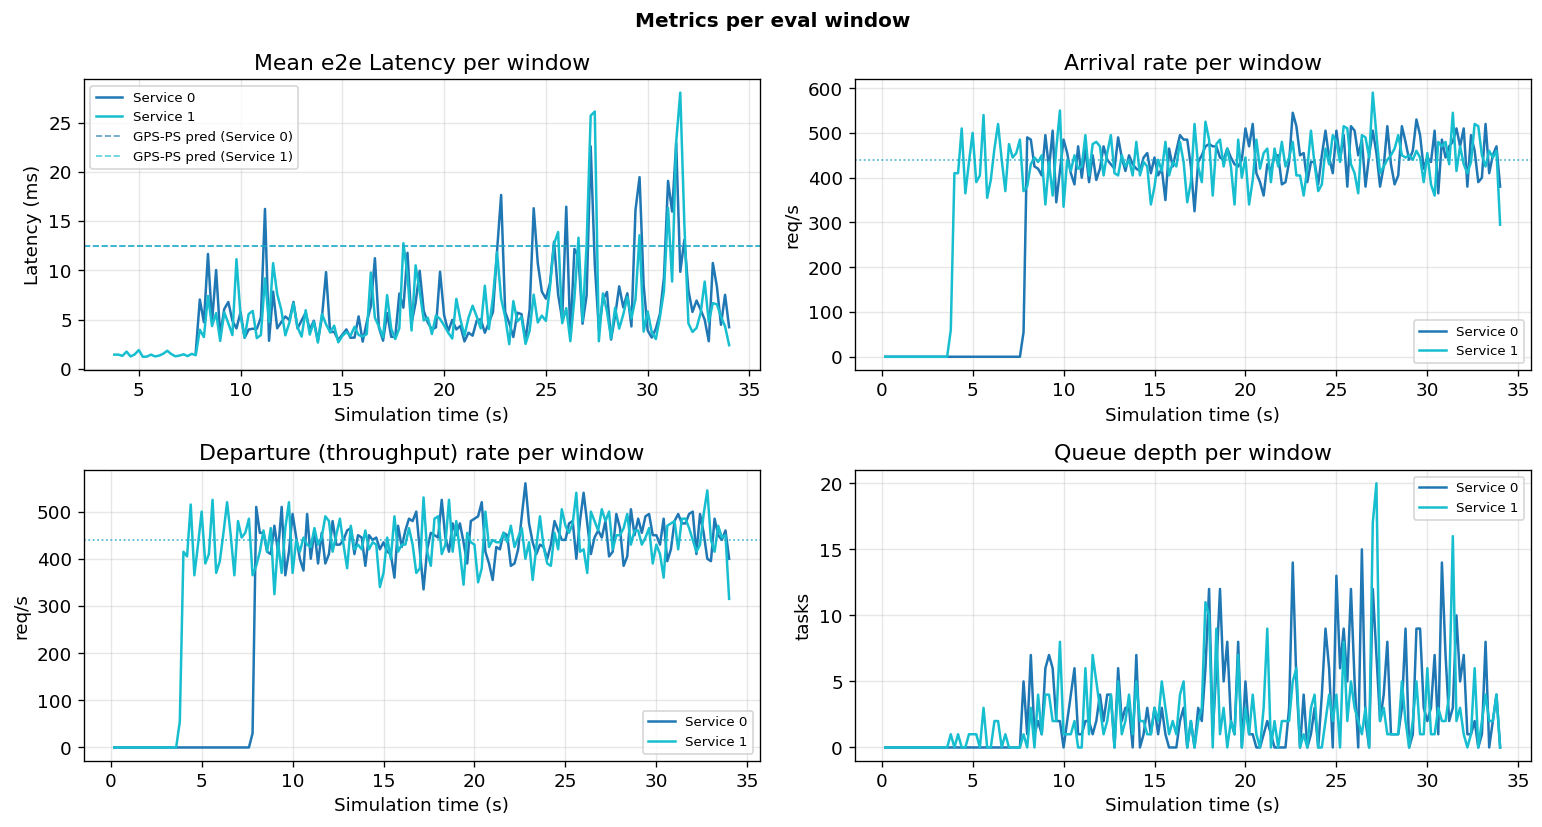

In [40]:
window_edges = np.arange(0.0, max(sim.t, EVAL_INTERVAL) + EVAL_INTERVAL, EVAL_INTERVAL)

# Build windowed metrics directly from completed traces so every service
# gets consistent plots even if the simulator's eval callback is sparse.
window_rows = []
for svc_id in range(NUM_SERVICES):
    traces = per_wf[svc_id]
    arrivals = np.array([x["t_arr"] for x in traces], dtype=float)
    departures = np.array([x["t_dep"] for x in traces], dtype=float)
    totals = np.array([x["total_ms"] for x in traces], dtype=float)

    cum_arr = 0
    cum_dep = 0
    for idx in range(len(window_edges) - 1):
        start = window_edges[idx]
        end = window_edges[idx + 1]
        arrival_mask = (arrivals >= start) & (arrivals < end)
        departure_mask = (departures >= start) & (departures < end)
        cum_arr += int(np.sum(arrival_mask))
        cum_dep += int(np.sum(departure_mask))
        completed_mask = departure_mask
        avg_latency = float(np.mean(totals[completed_mask])) if np.any(completed_mask) else np.nan

        window_rows.append({
            "t": end,
            "service_id": svc_id,
            "service_name": SERVICE_NAMES[svc_id],
            "arrival_rate": np.sum(arrival_mask) / EVAL_INTERVAL,
            "departure_rate": np.sum(departure_mask) / EVAL_INTERVAL,
            "avg_latency_ms": avg_latency,
            "queue_size": max(cum_arr - cum_dep, 0),
            "e2e_latency_ms": avg_latency,
        })

edf = pd.DataFrame(window_rows)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Metrics per eval window", fontsize=12, fontweight="bold")

palette = plt.colormaps["tab10"].resampled(NUM_SERVICES)
svc_colors = {i: palette(i / max(NUM_SERVICES - 1, 1)) for i in range(NUM_SERVICES)}
svc_labels = {i: SERVICE_NAMES[i] for i in range(NUM_SERVICES)}

def plot_metric(ax, col, ylabel, title, pred_vals=None, lam_vals=None):
    for svc_id, grp in edf.groupby("service_id"):
        svc_id = int(svc_id)
        ax.plot(grp["t"], grp[col], ms=5,
                color=svc_colors[svc_id], label=svc_labels[svc_id])
    if pred_vals is not None:
        for svc_id, val in pred_vals.items():
            ax.axhline(val, color=svc_colors[svc_id], linestyle="--", lw=1,
                       alpha=0.7, label=f"GPS-PS pred ({svc_labels[svc_id]})")
    if lam_vals is not None:
        for svc_id, val in lam_vals.items():
            ax.axhline(val, color=svc_colors[svc_id], linestyle=":", lw=1, alpha=0.5)
    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# GPS-PS T predictions per service (same demand logic for this shared pool)
gps_T_by_id = {i: pred_ps["services"][i]["T_ms"] for i in range(NUM_SERVICES)}
lambda_by_id = {i: SERVICE_LAMBDAS[i] for i in range(NUM_SERVICES)}

plot_metric(axes[0, 0], "e2e_latency_ms", "Latency (ms)",
            "Mean e2e Latency per window", pred_vals=gps_T_by_id)
plot_metric(axes[0, 1], "arrival_rate", "req/s",
            "Arrival rate per window", lam_vals=lambda_by_id)
plot_metric(axes[1, 0], "departure_rate", "req/s",
            "Departure (throughput) rate per window", lam_vals=lambda_by_id)
plot_metric(axes[1, 1], "queue_size", "tasks",
            "Queue depth per window")

plt.tight_layout()
plt.show()

## 9. Controlled Simulation with AnalyticalAgent

In [41]:
P_STAY = 1.0   # hyperparameter: probability of keeping current replica count

np.random.seed(SEED)

# ── Fresh app + node with the same topology ────────────────────────
app_ctrl = Application(topology=topology)
node_ctrl = Node(id=0, cpu=NODE_CPU, ram=8, freq=FREQ, thread_cpu_overhead=OVERHEAD)
app_ctrl.deploy_services({idx: node_ctrl for idx in range(NUM_SERVICES)})
for idx, replicas in enumerate(SERVICE_REPLICAS):
    app_ctrl.services[idx].threads = replicas

# ── Per-eval recorder that also runs the agent ─────────────────────
ctrl_eval_records = []
t_ref_ctrl = [0.0]

def make_ctrl_recorder(agent):
    seen = set()
    def on_eval(service_idx, service, accumulated, instant):
        key = (round(t_ref_ctrl[0], 6), service_idx)
        if key in seen:
            return None
        seen.add(key)
        action = agent.on_eval(service_idx, service, accumulated, instant)
        ctrl_eval_records.append({
            "t":             t_ref_ctrl[0],
            "service_idx":   service_idx,
            "service_name":  SERVICE_NAMES[service_idx],
            "threads":       service.threads,   # reflects previous agent action
            "chosen_r":      action,
            "arrival_rate":  accumulated["services"][service_idx]["arrival_rate"],
            "departure_rate":accumulated["services"][service_idx]["departure_rate"],
            "avg_latency_ms":accumulated["services"][service_idx]["avg_latency"] * 1000,
            "queue_size":    instant["services"][service_idx]["queue_size"],
            "e2e_latency_ms":accumulated["workflows"]["e2e_latencies"][service_idx] * 1000,
        })
        return action
    on_eval.agent = agent   # keep a reference for later inspection
    return on_eval

ctrl_agents = {
    idx: AnalyticalAgent(freq=FREQ, task_load=TASK_LOAD, overhead=OVERHEAD, p_stay=P_STAY, verbose=True)
    for idx in range(NUM_SERVICES)
}
ctrl_recorders = {idx: make_ctrl_recorder(ctrl_agents[idx]) for idx in range(NUM_SERVICES)}

# ── Run ────────────────────────────────────────────────────────────
sim_ctrl = Simulation(
    apps=[app_ctrl], units=[],
    iterations=ITERATIONS, eval_interval=EVAL_INTERVAL, timeout=TIMEOUT,
)
_orig_fwd_ctrl = sim_ctrl.forward
def _fwd_hook_ctrl(event):
    _orig_fwd_ctrl(event)
    t_ref_ctrl[0] = sim_ctrl.t
sim_ctrl.forward = _fwd_hook_ctrl

sim_ctrl.run(agents=ctrl_recorders)
print(f"Controlled simulation finished at t={sim_ctrl.t:.2f} s  ({len(sim_ctrl.history)} traces)")
for idx in range(NUM_SERVICES):
    recs = [r for r in ctrl_eval_records if r["service_idx"] == idx]
    chosen = [r["chosen_r"] for r in recs]
    print(f"  {SERVICE_NAMES[idx]}: mean r={np.mean(chosen):.2f}, "
          f"changes={int((np.diff(chosen) != 0).sum())}")

Services: 2
Tasktrees: 2
[0]
[1]
Labels: {0: 0, 1: 1}
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 1] STAY   r=1  λ=0.0  (λ=0 (no load yet))
  [Agent 0] STAY   r=1  λ=0.

,[Passive] T̄ (ms),[Passive] thr/s,[Ctrl] T̄ (ms),[Ctrl] thr/s
Service,,,,
Service 0,6.9921,445.3710,6.4732,438.3387
Service 1,5.9204,438.6361,6.2483,445.5650


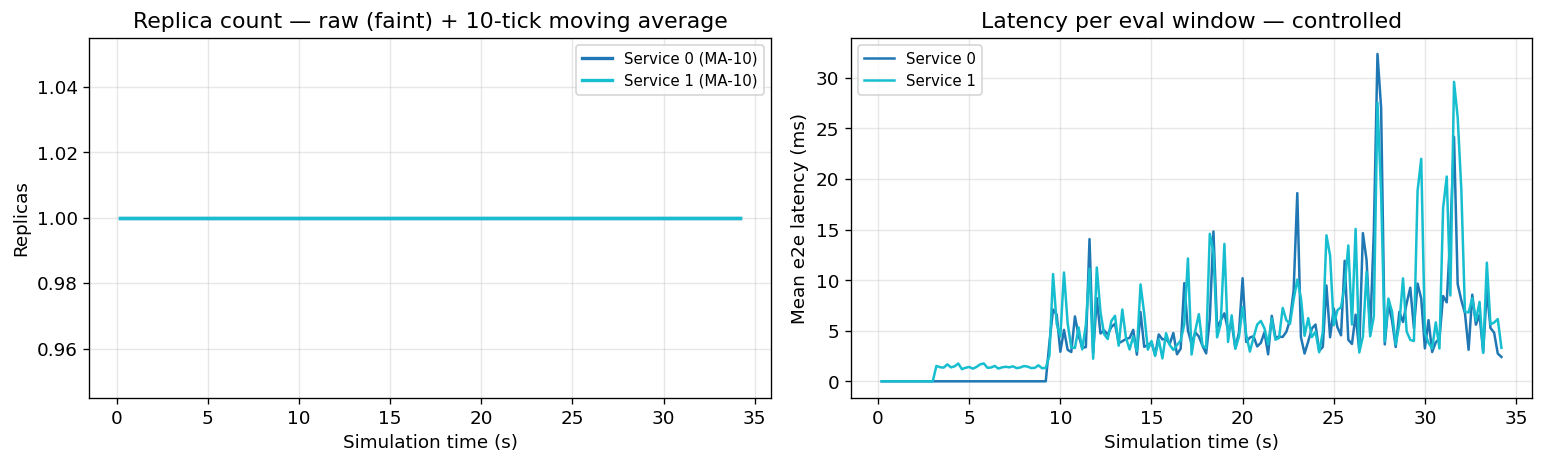

Saved run artifacts to results/queueing_game_simulator_20260522_211152_677578
  PDF: results/queueing_game_simulator_20260522_211152_677578/controlled_latency_and_replicas.pdf
  Replot script: results/queueing_game_simulator_20260522_211152_677578/replot_controlled_run.py


In [42]:
# ── Parse traces from controlled simulation ────────────────────────
wf_task_id_ctrl = {wf.id: wf.initial_task.id for wf in app_ctrl.workflows}
per_wf_ctrl: dict[int, list] = {wf_id: [] for wf_id in range(NUM_SERVICES)}

for trace_id, data in sim_ctrl.history.items():
    if data["status"] != 1:
        continue
    for wf_id, tid in wf_task_id_ctrl.items():
        if tid in data:
            ts = data[tid]
            if len(ts) >= 3:
                per_wf_ctrl[wf_id].append({
                    "t_arr": ts[0], "t_dep": ts[2],
                    "wait_ms":  (ts[1] - ts[0]) * 1000,
                    "exec_ms":  (ts[2] - ts[1]) * 1000,
                    "total_ms": (ts[2] - ts[0]) * 1000,
                })

# ── Comparison table: passive vs. controlled ───────────────────────
rows = []
for wf_id in range(NUM_SERVICES):
    p, c = per_wf[wf_id], per_wf_ctrl[wf_id]
    p_span = p[-1]["t_dep"] - p[0]["t_arr"] if len(p) > 1 else 1.0
    c_span = c[-1]["t_dep"] - c[0]["t_arr"] if len(c) > 1 else 1.0
    rows.append({
        "Service":              SERVICE_NAMES[wf_id],
        "[Passive] T̄ (ms)":    np.mean([x["total_ms"] for x in p]) if p else float("nan"),
        "[Passive] thr/s":     len(p) / p_span if p else float("nan"),
        "[Ctrl] T̄ (ms)":      np.mean([x["total_ms"] for x in c]) if c else float("nan"),
        "[Ctrl] thr/s":        len(c) / c_span if c else float("nan"),
    })

from datetime import datetime
from pathlib import Path
import json
from textwrap import dedent

# ── Replica count, moving average, and latency over time ──────────
MA_WINDOW = 10   # eval ticks

cedf = pd.DataFrame(ctrl_eval_records)
palette = plt.colormaps["tab10"].resampled(NUM_SERVICES)
svc_colors = {i: palette(i / max(NUM_SERVICES - 1, 1)) for i in range(NUM_SERVICES)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for svc_id, grp in cedf.groupby("service_idx"):
    svc_id = int(svc_id)
    c = svc_colors[svc_id]
    ma = grp["chosen_r"].rolling(MA_WINDOW, min_periods=1).mean()
    axes[0].step(grp["t"], grp["chosen_r"], where="post",
                 color=c, alpha=0.3, linewidth=1)
    axes[0].plot(grp["t"], ma,
                 color=c, linewidth=2, label=f"{SERVICE_NAMES[svc_id]} (MA-{MA_WINDOW})")
    axes[1].plot(grp["t"], grp["e2e_latency_ms"],
                 color=c, label=SERVICE_NAMES[svc_id])

axes[0].set_xlabel("Simulation time (s)")
axes[0].set_ylabel("Replicas")
axes[0].set_title(f"Replica count — raw (faint) + {MA_WINDOW}-tick moving average")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Simulation time (s)")
axes[1].set_ylabel("Mean e2e latency (ms)")
axes[1].set_title("Latency per eval window — controlled")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

comparison_df = pd.DataFrame(rows).set_index("Service")
display(comparison_df)

run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
run_dir = Path("results") / f"queueing_game_simulator_{run_stamp}"
run_dir.mkdir(parents=True, exist_ok=True)

control_traces = []
for wf_id, traces in per_wf_ctrl.items():
    for trace_idx, trace in enumerate(traces):
        control_traces.append({
            "service_id": wf_id,
            "service_name": SERVICE_NAMES[wf_id],
            "trace_idx": trace_idx,
            **trace,
        })

cedf.to_csv(run_dir / "controlled_eval_records.csv", index=False)
comparison_df.reset_index().to_csv(run_dir / "comparison_table.csv", index=False)
pd.DataFrame(control_traces).to_csv(run_dir / "controlled_trace_details.csv", index=False)

if "edf" in globals():
    edf.to_csv(run_dir / "passive_window_metrics.csv", index=False)

if "df" in globals():
    df.reset_index().to_csv(run_dir / "analytics_vs_simulation.csv", index=False)

metadata = {
    "created_at": run_stamp,
    "num_services": NUM_SERVICES,
    "service_names": SERVICE_NAMES,
    "service_lambdas": [float(x) for x in SERVICE_LAMBDAS],
    "service_replicas": [int(x) for x in SERVICE_REPLICAS],
    "freq": int(FREQ),
    "task_load": int(TASK_LOAD),
    "overhead": int(OVERHEAD),
    "node_cpu": int(NODE_CPU),
    "iterations": int(ITERATIONS),
    "eval_interval": float(EVAL_INTERVAL),
    "timeout": float(TIMEOUT),
    "seed": int(SEED),
    "p_stay": float(P_STAY),
    "artifacts": {
        "controlled_eval_records": "controlled_eval_records.csv",
        "comparison_table": "comparison_table.csv",
        "controlled_trace_details": "controlled_trace_details.csv",
        "passive_window_metrics": "passive_window_metrics.csv",
        "analytics_vs_simulation": "analytics_vs_simulation.csv",
        "plot_pdf": "controlled_latency_and_replicas.pdf",
        "replot_script": "replot_controlled_run.py",
    },
}

(run_dir / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

replot_script = dedent("""\
#!/usr/bin/env python3
from pathlib import Path
import argparse

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd



def build_plot(run_dir):
    run_dir = Path(run_dir)
    data = pd.read_csv(run_dir / "controlled_eval_records.csv")
    data = data.sort_values(["service_idx", "t"]).reset_index(drop=True)

    service_ids = [int(x) for x in sorted(data["service_idx"].unique())]
    service_names = {
        int(row.service_idx): row.service_name
        for row in data[["service_idx", "service_name"]].drop_duplicates().itertuples(index=False)
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cmap = plt.get_cmap("tab10")

    for color_index, service_id in enumerate(service_ids):
        group = data[data["service_idx"] == service_id]
        color = cmap(color_index % 10)
        moving_average = group["chosen_r"].rolling(10, min_periods=1).mean()
        axes[0].step(group["t"], group["chosen_r"], where="post", color=color, alpha=0.3, linewidth=1)
        axes[0].plot(
            group["t"],
            moving_average,
            color=color,
            linewidth=2,
            label=f"{service_names.get(service_id, f'Service {service_id}')} (MA-10)",
        )
        axes[1].plot(
            group["t"],
            group["e2e_latency_ms"],
            color=color,
            label=service_names.get(service_id, f"Service {service_id}"),
        )

    axes[0].set_xlabel("Simulation time (s)")
    axes[0].set_ylabel("Replicas")
    axes[0].set_title("Replica count — raw + 10-tick moving average")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("Simulation time (s)")
    axes[1].set_ylabel("Mean e2e latency (ms)")
    axes[1].set_title("Latency per eval window — controlled")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig



def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("run_dir", nargs="?", default=".")
    parser.add_argument("--output", default="controlled_latency_and_replicas_reloaded.pdf")
    args = parser.parse_args()

    run_dir = Path(args.run_dir).resolve()
    fig = build_plot(run_dir)
    output_path = run_dir / args.output
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)
    print(f"saved {output_path}")



if __name__ == "__main__":
    main()
""")

script_path = run_dir / "replot_controlled_run.py"
script_path.write_text(replot_script, encoding="utf-8")

pdf_path = run_dir / "controlled_latency_and_replicas.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved run artifacts to {run_dir}")
print(f"  PDF: {pdf_path}")
print(f"  Replot script: {script_path}")